In [ ]:
#implementing a SVM classifier using cvxopt using Primal fomrulation for SVM 

In [5]:
from cvxopt import matrix, solvers
import pandas as pd
import numpy as np

In [6]:
#step1 load in the data 

train = pd.read_csv('train.csv', header = None)
Y = train.iloc[:4000, 0].values
X = train.iloc[:4000, 1:].values

print(X)
print(Y)

#convert the labesl to -1 or 1 as the constraints for primal say that yi​(wTxi​+b) ≥ 1−ξi​ which means yi must be +1 for one class and -1 for the other class
Y = np.where(Y == 0, -1, 1).astype(float)

#standardize the features
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

#obtain the n= number of samples and d = number of features
n, d = X.shape
print(n)
print(d)

[[-0.36 -0.91 -0.99 ...  0.3   2.44 -1.26]
 [-1.4  -1.9   0.09 ... -0.2  -0.92 -0.46]
 [-0.43  1.45 -0.68 ...  0.12  0.01 -0.56]
 ...
 [-0.57  0.14 -0.62 ...  0.    0.38 -0.82]
 [ 0.4   0.16 -0.49 ...  0.89  0.21  1.09]
 [ 0.86 -0.23 -2.01 ...  0.21  0.68  2.49]]
[0. 1. 1. ... 1. 1. 1.]
4000
200


In [7]:
#create the matrix form by converting problem into cannocial form 1/2 * uT * P * u  + qT * u
# u = [weight ^d , b , slack ^ n]

C = 1.0 #fine tuned later

t = d + 1 + n #total number of variables
#u = matrix(np.zeros(t))

#build P whihc is an indentityy matrix for 
P = np.zeros((t,t))
P[0:d, 0:d] = np.eye(d)
P = matrix(P)

q = np.zeros(t)
q[d+1:] = C
q = matrix(q)

#f = 0.5 * u.T @ P @ u + q.T @ u 

In [8]:
#SVM primal constraints
G_margin = np.zeros((n,t))
for i in range(n):
    G_margin[i, 0:d] = -Y[i] * X[i]
    G_margin[i,d] = -Y[i]
    G_margin[i, d+1+i] = -1
h_margin = -np.ones(n)


# Slack constraints
G_slack = np.zeros((n, d + 1 + n))
for i in range(n):
    G_slack[i, d+1+i] = -1
h_slack = np.zeros(n)


#stacks them
G = np.vstack([G_margin, G_slack])
h = np.hstack([h_margin, h_slack])


In [ ]:

# Convert to cvxopt matrices
G = matrix(G) 
h = matrix(h)  

solvers.options['show_progress'] = True  

solution = solvers.qp(P, q, G, h)

u_opt = np.array(solution['x']).flatten()  # convert to NumPy array

w_opt = u_opt[0:d]          # first d entries: weights
b_opt = u_opt[d]            # bias
xi_opt = u_opt[d+1:]        # remaining n entries: slack variables

     pcost       dcost       gap    pres   dres
 0: -3.2471e+03  1.0925e+04  7e+04  5e+00  2e+02
 1:  5.1739e+03 -5.1035e+03  1e+04  7e-01  2e+01
 2:  1.7765e+03 -9.0342e+02  3e+03  1e-01  5e+00
 3:  8.7878e+02 -2.4989e+02  1e+03  6e-02  2e+00
 4:  5.1371e+02  1.4379e+01  6e+02  2e-02  7e-01
 5:  3.1702e+02  1.4717e+02  2e+02  6e-03  2e-01
 6:  2.5887e+02  1.8500e+02  8e+01  2e-03  6e-02
 7:  2.3910e+02  1.9677e+02  4e+01  7e-04  2e-02
 8:  2.2856e+02  2.0258e+02  3e+01  2e-04  8e-03
 9:  2.1979e+02  2.0795e+02  1e+01  8e-05  2e-03
10:  2.1691e+02  2.0960e+02  7e+00  2e-05  8e-04
11:  2.1571e+02  2.1032e+02  5e+00  1e-05  4e-04
12:  2.1410e+02  2.1154e+02  3e+00  4e-06  1e-04
13:  2.1354e+02  2.1196e+02  2e+00  2e-06  7e-05
14:  2.1313e+02  2.1228e+02  9e-01  1e-06  3e-05
15:  2.1283e+02  2.1251e+02  3e-01  1e-09  4e-08
16:  2.1269e+02  2.1264e+02  5e-02  2e-10  6e-09
17:  2.1267e+02  2.1266e+02  7e-03  7e-12  2e-10
18:  2.1266e+02  2.1266e+02  2e-04  2e-13  8e-12
Optimal solution foun

In [10]:
#now we need to validate the 4500 points
# Training data
X_train = X  
Y_train = Y 

# Validation data (remaining rows)
X_val = train.iloc[4000:, 1:].values  # rows 4000 to 8499
Y_val = train.iloc[4000:, 0].values

# Convert labels
Y_val = np.where(Y_val == 0, -1, 1).astype(float)

# Standardize features (use training mean/std!)
X_val = (X_val - X_train.mean(axis=0)) / (X_train.std(axis=0) + 1e-8)

print(X_val)
print(Y_val)

[[-0.26  0.66  0.31 ... -1.79  1.48  0.01]
 [ 0.47 -0.01 -0.5  ... -0.19  1.84 -0.54]
 [ 0.39  1.57 -1.69 ... -0.11  2.06 -0.55]
 ...
 [ 1.18  0.78 -0.02 ... -0.63  0.29 -0.96]
 [-0.55  1.16 -0.56 ...  2.97 -2.66 -1.9 ]
 [ 0.8  -0.97 -0.15 ... -1.58  0.35  1.06]]
[-1.  1. -1. ...  1.  1. -1.]


In [11]:
#make the prediuctions:
# Decision function
y_val_pred = np.sign(X_val @ w_opt + b_opt)

# Accuracy
val_accuracy = np.mean(y_val_pred == Y_val)
print("Validation accuracy:", val_accuracy)


Validation accuracy: 0.8942222222222223


     pcost       dcost       gap    pres   dres
 0:  4.6627e-01  3.7608e+02  4e+04  3e+00  9e+03
 1:  1.3271e+00 -3.9077e+02  4e+02  3e-02  9e+01
 2:  1.2470e+00 -1.5366e+01  2e+01  1e-03  4e+00
 3:  1.0156e+00 -6.0228e-01  2e+00  8e-05  2e-01
 4:  4.8422e-01  2.6867e-01  2e-01  1e-15  4e-16
 5:  3.5060e-01  2.9738e-01  5e-02  6e-16  2e-16
 6:  3.4009e-01  3.0166e-01  4e-02  5e-16  2e-16
 7:  3.2262e-01  3.0998e-01  1e-02  4e-16  2e-16
 8:  3.1798e-01  3.1251e-01  5e-03  4e-16  2e-16
 9:  3.1539e-01  3.1417e-01  1e-03  4e-16  2e-16
10:  3.1475e-01  3.1466e-01  8e-05  4e-16  3e-16
11:  3.1470e-01  3.1470e-01  2e-06  4e-16  6e-16
12:  3.1470e-01  3.1470e-01  5e-08  4e-16  6e-15
Optimal solution found.
C=0.000100, Training Accuracy=0.8792, Validation Accuracy=0.9144
     pcost       dcost       gap    pres   dres
 0:  5.4127e-01  3.7790e+02  4e+04  3e+00  9e+03
 1:  3.1275e+00 -3.8739e+02  4e+02  3e-02  9e+01
 2:  3.0668e+00 -1.2359e+01  2e+01  1e-03  3e+00
 3:  2.2684e+00  5.1339e-01  2e

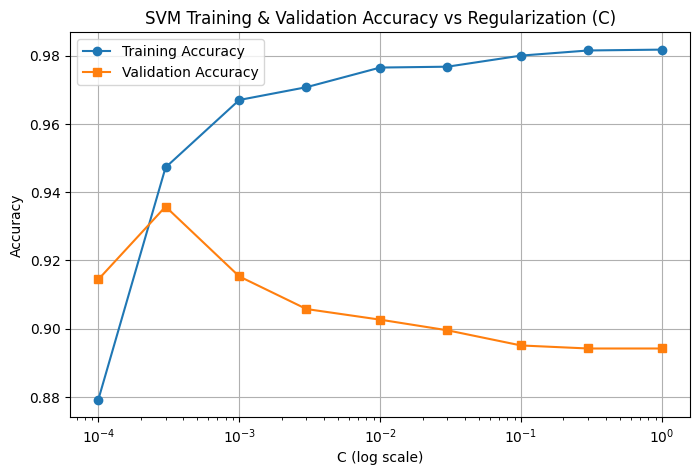

In [18]:
#Hyperparameter tuninig - this is tuning the C value that I randomly chose earlier

import matplotlib.pyplot as plt
import numpy as np

C_vals = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]

results_val = []
results_train = []

for val in C_vals:
    q = np.zeros(t)
    q[d+1:] = val
    q = matrix(q)

    solution = solvers.qp(P, q, G, h)
    u_opt = np.array(solution['x']).flatten()

    w_opt = u_opt[0:d]
    b_opt = u_opt[d]

    # Validation accuracy
    y_val_pred = np.sign(X_val @ w_opt + b_opt)
    acc_val = np.mean(y_val_pred == Y_val)
    results_val.append(acc_val)

    # Training accuracy
    y_train_pred = np.sign(X_train @ w_opt + b_opt)
    acc_train = np.mean(y_train_pred == Y_train)
    results_train.append(acc_train)

    print(f"C={val:.6f}, Training Accuracy={acc_train:.4f}, Validation Accuracy={acc_val:.4f}")

# Plot accuracy vs C
plt.figure(figsize=(8,5))
plt.semilogx(C_vals, results_train, marker="o", label="Training Accuracy")
plt.semilogx(C_vals, results_val, marker="s", label="Validation Accuracy")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("SVM Training & Validation Accuracy vs Regularization (C)")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
#now use on testing set
# Rebuild q with best C
q = np.zeros(t)
q[d+1:] = 0.0003
q = matrix(q, tc='d')

# Solve QP
solution = solvers.qp(P, q, G, h)
u_opt = np.array(solution['x']).flatten()
w_final = u_opt[:d]
b_final = u_opt[d]


     pcost       dcost       gap    pres   dres
 0:  5.4127e-01  3.7790e+02  4e+04  3e+00  9e+03
 1:  3.1275e+00 -3.8739e+02  4e+02  3e-02  9e+01
 2:  3.0668e+00 -1.2359e+01  2e+01  1e-03  3e+00
 3:  2.2684e+00  5.1339e-01  2e+00  1e-15  1e-15
 4:  8.8780e-01  5.5666e-01  3e-01  9e-16  4e-16
 5:  7.0951e-01  6.1446e-01  1e-01  5e-16  4e-16
 6:  6.7477e-01  6.3426e-01  4e-02  4e-16  4e-16
 7:  6.5594e-01  6.4532e-01  1e-02  4e-16  5e-16
 8:  6.5195e-01  6.4789e-01  4e-03  4e-16  6e-16
 9:  6.5016e-01  6.4921e-01  1e-03  4e-16  9e-16
10:  6.4972e-01  6.4954e-01  2e-04  4e-16  2e-15
11:  6.4963e-01  6.4961e-01  2e-05  4e-16  4e-15
12:  6.4962e-01  6.4962e-01  8e-07  4e-16  1e-14
13:  6.4962e-01  6.4962e-01  2e-08  4e-16  7e-14
Optimal solution found.


In [16]:
test = pd.read_csv('test.csv', header = None)

Y_Test = test.iloc[:, 0].values
X_Test = test.iloc[:, 1:].values
Y_Test = np.where(Y_Test == 0, -1, 1).astype(float)
X_Test = (X_Test - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)


In [17]:
y_test_pred = np.sign(X_Test @ w_final + b_final)
test_accuracy = np.mean(y_test_pred == Y_Test)
print("Test accuracy:", test_accuracy)


Test accuracy: 0.934
